# Tutorial 01 — VASP Band Structure with Atomate2

## Goal
Compute the **electronic band structure and density of states (DOS)** of MgO using VASP via an atomate2 workflow.


## Workflow overview

`RelaxBandStructureMaker` constructs a multi-step atomate2 `Flow` consisting of:

| Step | Job name | Purpose |
|------|----------|---------|
| 1 | `relax` | Geometry optimisation  |
| 2 | `static` | Self-consistent DFT calculation to obtain a converged charge density |
| 3 | `non-scf uniform` | Non-self-consistent calculation on a uniform k-point grid → DOS |
| 4 | `non-scf line` | Non-self-consistent calculation along high-symmetry k-paths → band structure |

Steps 3 and 4 both depend on the charge density from step 2, so they can run in parallel.

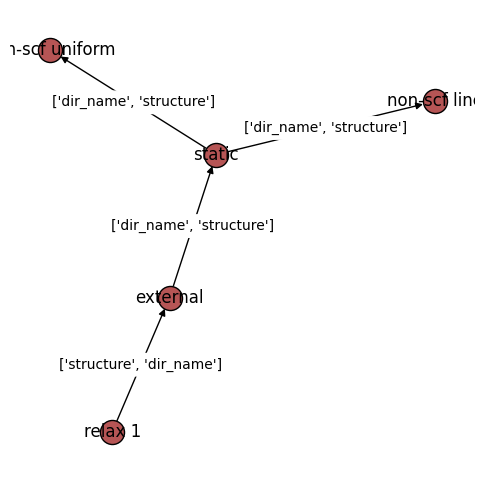

In [2]:
from fireworks import LaunchPad
from atomate2.vasp.flows.core import RelaxBandStructureMaker
from atomate2.vasp.powerups import add_metadata_to_flow
from jobflow.managers.fireworks import flow_to_workflow
from pymatgen.core import Structure
import networkx as nx

# construct a rock salt MgO structure
mgo_structure = Structure(
    lattice=[[0, 2.13, 2.13], [2.13, 0, 2.13], [2.13, 2.13, 0]],
    species=["Mg", "O"],
    coords=[[0, 0, 0], [0.5, 0.5, 0.5]],
)

# make a band structure flow to optimise the structure and obtain the band structure
bandstructure_flow = RelaxBandStructureMaker().make(mgo_structure)
#show diagram of the flow
bandstructure_flow.draw_graph(figsize=(6, 6), layout_function=nx.nx_agraph.graphviz_layout).show()

In [3]:
# (Optional) add metadata to the flow task document.
# Could be useful to filter specific results from the database.
# For e.g., adding material project ID for the compound, use following lines
bandstructure_flow = add_metadata_to_flow(
    flow=bandstructure_flow,
    additional_fields={"mp_id": "mp-190"},
)
#set the name of the worker to the name you set in my_fworker.yaml
worker = "my_fworker"
#by specifying the worker the rlaunch command will only run the tasks if the worker specified
#  in the flow matches the worker specified in the my_fworker.yaml file used in rlaunch -w my_fworker.yaml ...
bandstructure_flow.update_config({"manager_config": {"_fworker": worker}})

# convert the flow to a fireworks WorkFlow object
wf = flow_to_workflow(bandstructure_flow)

# submit the workflow to the FireWorks launchpad
lpad = LaunchPad.from_file("../my_launchpad.yaml")  
lpad.add_wf(wf)

2026-03-04 11:30:52,203 INFO Added a workflow. id_map: {-5: 803, -4: 804, -3: 805, -2: 806, -1: 807}


{-5: 803, -4: 804, -3: 805, -2: 806, -1: 807}

## Step 2 — Submit the workflow to FireWorks

The cell above does three things:

1. **Adds metadata** (`add_metadata_to_flow`): attaches extra fields (here, the Materials Project ID `mp-190`) to every task document stored in the database. This makes it easy to filter results later, e.g. `store.query({"mp_id": "mp-190"})`.

2. **Assigns a worker** (`update_config`): tells FireWorks which compute resource to use. The worker name must match the `name` field in `my_fworker.yaml`.

3. **Submits to the LaunchPad** (`lpad.add_wf(wf)`): serialises the flow and pushes it to the FireWorks MongoDB. The returned dict maps internal jobflow IDs to FireWorks FW IDs.

### Monitoring job status

After submitting, open a terminal and use:

```bash
# List all fireworks and their status (READY / RUNNING / COMPLETED / FIZZLED)
lpad get_fws


# Or use the web GUI
lpad webgui
```

Once all four jobs have status `COMPLETED`, continue to `analyse_bandstructure.ipynb` to plot the results.